# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from arch import arch_model

### Загрузка исторических цен акций (закрытия на конец дня) и расчёт ежедневных доходностей

In [40]:
tickers = ['MSFT', 'AAPL']
start_date = '2023-01-01'
end_date = '2025-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

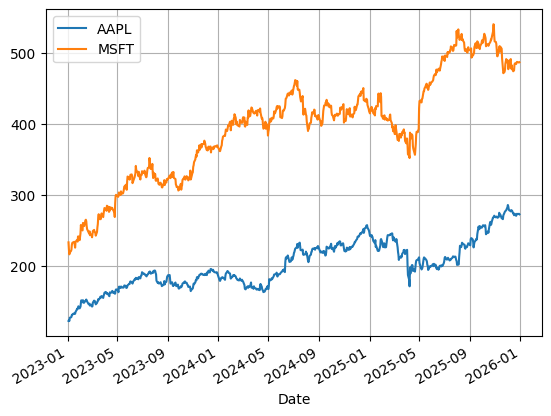

In [41]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### График доходностей


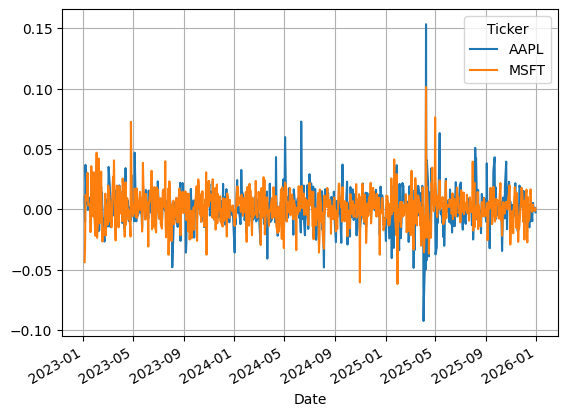

In [42]:
returns.plot()
plt.grid()
plt.show()

### Описательные статистики дневных доходностей

In [43]:
returns.describe()

Ticker,AAPL,MSFT
count,750.000000,750.000000
mean,0.001191,0.001085
std,0.016137,0.014624
min,-0.092456,-0.061809
25%,-0.006654,-0.006728
50%,0.001400,0.001252
75%,0.008725,0.009156
max,0.153288,0.101337


### Графики Бокса-Вискера дневных доходностей

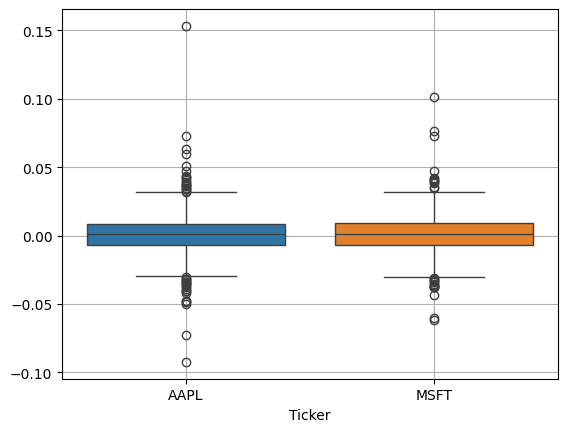

In [44]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

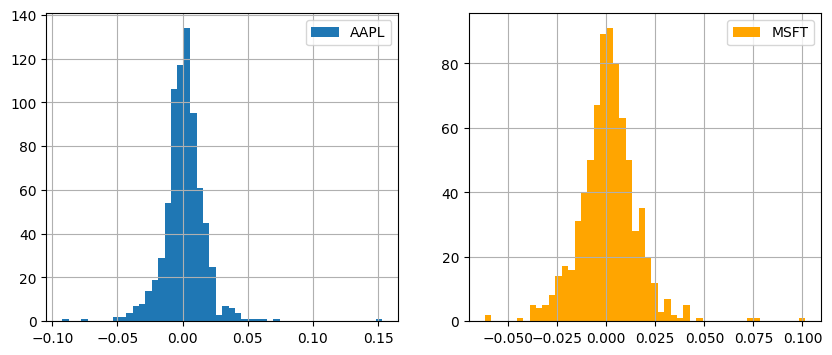

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### Критерии стационарности ряда: ADF-test и KPSS-test

In [46]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -27.857266
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.439110818166223), '5%': np.float64(-2.8654065210185795), '10%': np.float64(-2.568828945705979)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.207103
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -13.891034
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4391580196774494), '5%': np.float64(-2.8654273226340554), '10%': np.float64(-2.5688400274762397)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.101721
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/var/folders/_r/xsq315px3ggfhq10dxmkl3fr0000gn/T/ipykernel_3791/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/_r/xsq315px3ggfhq10dxmkl3fr0000gn/T/ipykernel_3791/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


### p-value обоих тестов близко к нулю, ряды стационарны. Значит, можно на их основе построить GARCH-модель

## 2. Построение модели GARCH(1,1) на основе случайных величин

Модель GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) для временного ряда доходностей $r_t$ записывается как: $$\begin{gathered} r_t = \mu + \varepsilon_t, \\ \varepsilon_t=\sigma_t z_t, \\ \sigma^2_t=\omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} \end{gathered} $$  где $r_t$ - исследуемый ряд, $z_t$ - случайные величины, $\omega > 0$, $\alpha, \beta \ge 0$, $\alpha + \beta < 1$ (условие стационарности). $\mu$ задаётся в зависимости от центрированности ряда.
На реальных данных параметры чаще всего оцениваются методом максимального правдоподобия. Процесс $r_t$ должен быть процессом с условной гетероскедакстичностью, т. е. может быть представлен следующим образом $r_t = \sigma_t z_t$  

Для предсказания будущей волатильности используется формулы: $$\begin{gathered} \hat{\sigma}^2_{t+1} = \omega + \alpha \varepsilon^2_t + \beta \sigma^2_{t} \\ \hat{\sigma}^2_{t+h} = \omega + (\alpha + \beta) \hat{\sigma}^2_{t+h-1},\ \ h=2,3,\dots \end{gathered}$$

В рамках лабораторной работы для симуляции временных рядов и построения на них модели GARCH, зададим истинные значения $\omega, \alpha, \beta$ и построим ряды из приведённых формул, а затем оценим, как модель оценит эти параметры. $\omega = 0.1, \alpha = 0.1, \beta = 0.8$

In [47]:
def simulate_garch_process(omega: float, alpha: float, beta: float, T: int, distribution, *args):
    r = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / (1 - alpha - beta)

    for t in range(1, T):
        sigma2[t] = omega + alpha * (r[t-1]**2) + beta * sigma2[t-1]
        r[t] = np.sqrt(sigma2[t]) * distribution(*args)

    return r, sigma2

OMEGA = 0.1
ALPHA = 0.1
BETA = 0.8
T = 1000
PREDICTION_STEPS = 20

In [48]:
from typing import Literal

from scipy.optimize import minimize, LinearConstraint
from scipy import special

class garch11:
    def __init__(self, dist: Literal['norm', "vg", "as"]):
        self.dist = dist
        self.conditional_volatility = np.zeros(1)

    def fit(self, sample):
        init_params = [0., 0.01, 0.1, 0.8]
        bounds = [(None, None), (1e-6, None), (0, 1), (0, 1)]
        constraint = LinearConstraint([[0, 0, 1, 1]], ub=0.999)

        result = None
        sigma2, mu, omega, alpha, beta, eps = np.zeros(0), 0., 0., 0., 0., np.zeros(0)
        T = len(sample)

        if self.dist == 'norm':
            result = minimize(self.likelihood_normal, init_params,
                              method='SLSQP', args=(sample),
                              bounds=bounds, constraints=constraint)
            mu, omega, alpha, beta = result.x
            
        elif self.dist == 'vg':
            result = minimize(self.likelihood_vg, init_params,
                              method='SLSQP', args=(sample),
                              bounds=bounds, constraints=constraint)
            mu, omega, alpha, beta = result.x
        elif self.dist == 'as':
            result = minimize(self.likelihood_as, init_params,
                              method='SLSQP', args=(sample),
                              bounds=bounds, constraints=constraint)
            mu, omega, alpha, beta = result.x
        else:
            ValueError('Unknown distribution')
        
        eps = sample - mu
        sigma2 = np.zeros(T)
        sigma2[0] = np.var(eps)
        for t in range(1,T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        self.resid = sample
        self.conditional_volatility = sigma2
        self.alpha = alpha
        self.omega = omega
        self.beta = beta
        self.mu = mu
        self.eps = eps

        return result
    
    def predict(self, horizon: int):
        if self.conditional_volatility is None:
            raise RuntimeError("Модель не обучена. Сначала вызовите fit().")
        
        forecast = np.zeros(horizon)
        last_sigma2 = self.conditional_volatility[-1]
        last_eps2 = self.eps[-1]**2
        
        forecast[0] = self.omega + self.alpha * last_eps2 + self.beta * last_sigma2
        
        persistence = self.alpha + self.beta
        for h in range(1, horizon):
            forecast[h] = self.omega + persistence * forecast[h-1]
        
        return forecast
    
    def likelihood_normal(self, params, sample):
            mu, omega, alpha, beta = params
            eps = sample - mu
            T = len(sample)

            sigma2 = np.zeros(T)
            sigma2[0] = omega / (1 - alpha - beta) if (alpha + beta) < 1 else np.var(eps)

            for t in range(1,T):
                sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

            loglik = -0.5 * np.sum(np.log(sigma2) + (eps**2) / sigma2)
            return -loglik
    
    def likelihood_vg(self, params, sample):
        def vg_pdf_one_point(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0)->float:
            temp1 = 2.0 / ( sigma*(2.0*np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
            temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
            temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
            temp4 = special.kv(1/nu - 0.5, abs(x-c)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
            return temp1*temp2*temp3*temp4
        
        def vg_moments_method(x):
            mu = np.mean(x)
            sigma_squared = np.mean( (x-mu)**2 )
            beta = np.mean( (x-mu)**3 ) / np.mean( (x-mu)**2 )**1.5
            kapa = np.mean( (x-mu)**4 ) / np.mean( (x-mu)**2 )**2
            sigma = sigma_squared**0.5
            nu = kapa/3.0 - 1.0
            theta = sigma*beta / (3.0*nu)
            c = mu - theta
            return (c, sigma, theta, nu)

        mu, omega, alpha, beta = params
        eps = sample - mu
        T = len(sample)
        sigma2 = np.zeros(T)
        sigma2[0] = omega / (1 - alpha - beta) if (alpha + beta) < 1 else np.var(eps)
        for t in range(1, T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

        loglik = 0.
        c_vg, sigma_vg, theta_vg, nu_vg = vg_moments_method(eps)
        for t in range(T):
            sigma2_t = sigma2[t]
            if sigma2_t <= 0:
                return 1e10 

            z = eps[t] / np.sqrt(sigma2_t)
            pdf_z = vg_pdf_one_point(z, c_vg, sigma_vg, theta_vg, nu_vg)
            if pdf_z <= 0:
                return 1e10
            
            loglik += -0.5 * np.log(sigma2_t) + np.log(pdf_z)
        
        return -loglik

    def likelihood_as(self, params, sample, p=0.4):
        mu, omega, alpha, beta = params
        eps = sample - mu
        T = len(sample)

        sigma2 = np.zeros(T)
        if (alpha + beta) < 1:
            sigma2[0] = omega / (1 - alpha - beta)
        else:
            sigma2[0] = np.var(eps)

        for t in range(1,T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        
        if np.any(sigma2 <= 0):
            return 1e10

        loglik = np.sum(np.log(sigma2) + (1.0/p) * (eps**2 / sigma2)**p)
        return loglik
    
    def summary(self):
        return f"mu: {self.mu}, omega: {self.omega}, alpha: {self.alpha}, beta: {self.beta}"

### 2.1. Нормальное распределение

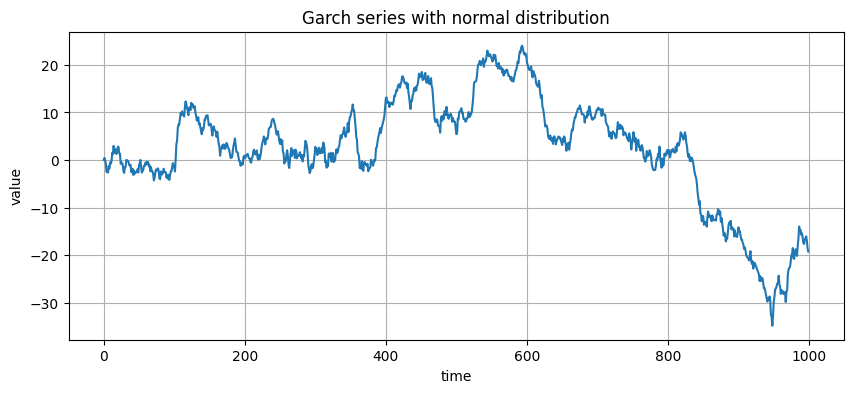

In [49]:
r_norm, sigma2_norm = simulate_garch_process(OMEGA, ALPHA, BETA, T, np.random.normal, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_norm))
plt.title("Garch series with normal distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [50]:
normal_model = garch11(dist='norm')
normal_model.fit(r_norm[:-PREDICTION_STEPS])
normal_model.summary()

'mu: -0.02249008366182594, omega: 0.15439749178293719, alpha: 0.09047736440327991, beta: 0.7463044875130185'

In [51]:
forecasts_normal = normal_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecasts_normal)


Прогноз дисперсии на 20 шагов:
[1.22674049 1.18091167 1.14256295 1.11047343 1.08362151 1.0611523
 1.04235048 1.02661746 1.01345235 1.00243603 0.99321777 0.98550409
 0.97904943 0.97364829 0.96912871 0.96534681 0.96218218 0.95953408
 0.9573182  0.95546398]


In [52]:
resid_norm = normal_model.resid  # r_t
cond_vol_norm = normal_model.conditional_volatility  # sigma_t
std_resid_norm = resid_norm / cond_vol_norm # z_t

#### Построим график оценённой волатильности / реальной

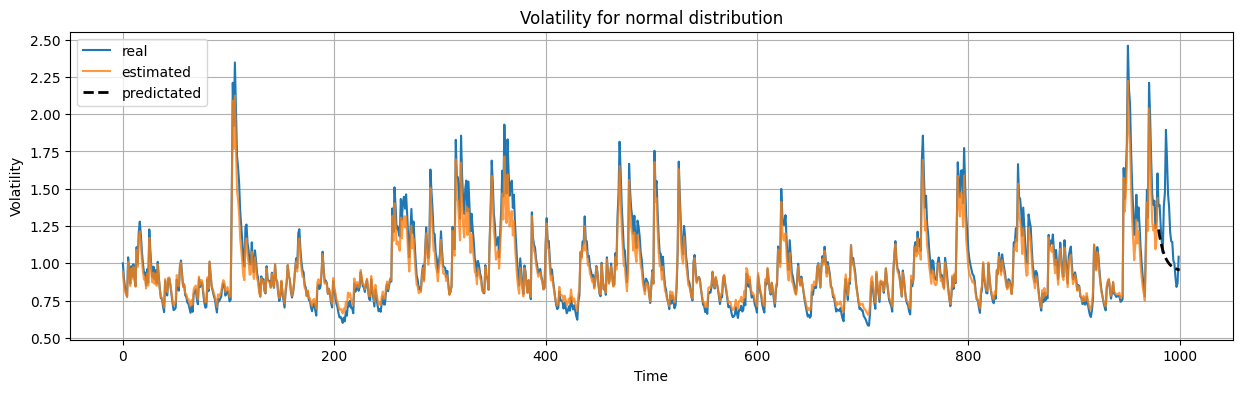

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_norm, label="real")
plt.plot(cond_vol_norm, color='tab:orange', label="estimated", alpha=0.8)

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS)
plt.plot(x_predicted, np.array(forecasts_normal), color='black', linestyle='--', linewidth=2, label="predictated")

plt.title("Volatility for normal distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Посчитаем среднюю квадратичную ошибку оценённой волатильности

In [54]:
norm_mse = ((normal_model.conditional_volatility - sigma2_norm[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.0047


#### Оценим параметры нормального распределения (математическое ожидание и дисперсию)

In [55]:
print(f"Estimated mean: {np.mean(std_resid_norm)}")
print(f"Estimated variance: {np.var(std_resid_norm)}")

Estimated mean: -0.03496385379739664
Estimated variance: 1.105222849426561


### 2.2. Variance Gamma

In [56]:
from scipy import special

def vg_rvs(mu, theta, sigma, nu):
    """
    Генерация случайных чисел из VG распределения
    """
    # 1. Генерируем случайное время из гамма-распределения
    # Параметры: shape = 1/nu, scale = nu [citation:3]
    g = np.random.gamma(shape=1/nu, scale=nu)
    
    # 2. Условное нормальное распределение:
    # VG = theta * g + sigma * sqrt(g) * N(0,1)
    # где g - сгенерированное гамма-время
    normal = np.random.normal(0, 1)
    vg = theta * g + sigma * np.sqrt(g) * normal + mu
    
    return vg

def vg_pdf_one_point(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function in a point x '''
	temp1 = 2.0 / ( sigma*(2.0*np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
	temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
	temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
	temp4 = special.kv(1/nu - 0.5, abs(x-c)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
	return temp1*temp2*temp3*temp4

def vg_pdf(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function of an array or a point x '''
	if isinstance(x, (int, float)): # works with lists and arrays
		return vg_pdf_one_point(x, c, sigma, theta, nu)
	else:
		return [vg_pdf_one_point(xi, c, sigma, theta, nu) for xi in x]

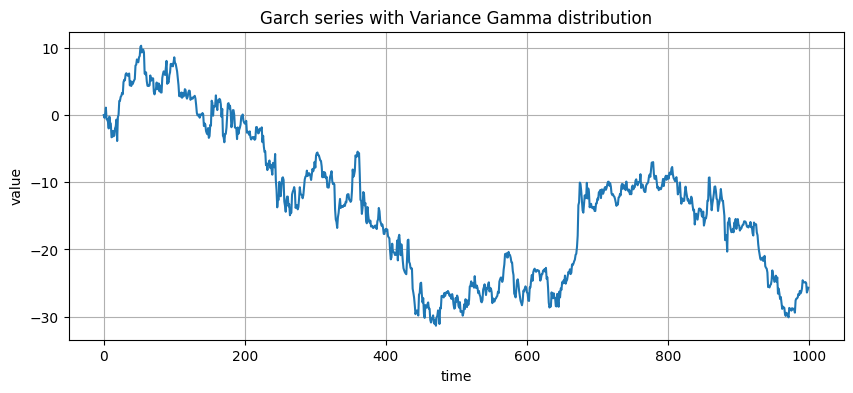

In [57]:
r_vg, sigma2_vg = simulate_garch_process(OMEGA, ALPHA, BETA, T, vg_rvs, 0, 0, 1, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_vg))
plt.title("Garch series with Variance Gamma distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [58]:
vg_model = garch11(dist='vg')
vg_model.fit(r_vg[:-PREDICTION_STEPS])
vg_model.summary()

'mu: 0.014977095802192107, omega: 0.09056160456290537, alpha: 0.08513628102031201, beta: 0.8220209964047225'

In [59]:
forecast_vg = vg_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_vg)


Прогноз дисперсии на 20 шагов:
[0.58953593 0.62536341 0.65786457 0.68734824 0.71409456 0.73835768
 0.76036815 0.78033511 0.79844828 0.81487977 0.82978572 0.84330776
 0.85557437 0.86670212 0.87679674 0.88595415 0.89426136 0.90179731
 0.90863359 0.91483518]


In [60]:
resid_vg = vg_model.resid  # r_t
cond_vol_vg = vg_model.conditional_volatility  # sigma_t
std_resid_vg = resid_vg / cond_vol_vg # z_t

#### Построим график оценённой волатильности / реальной

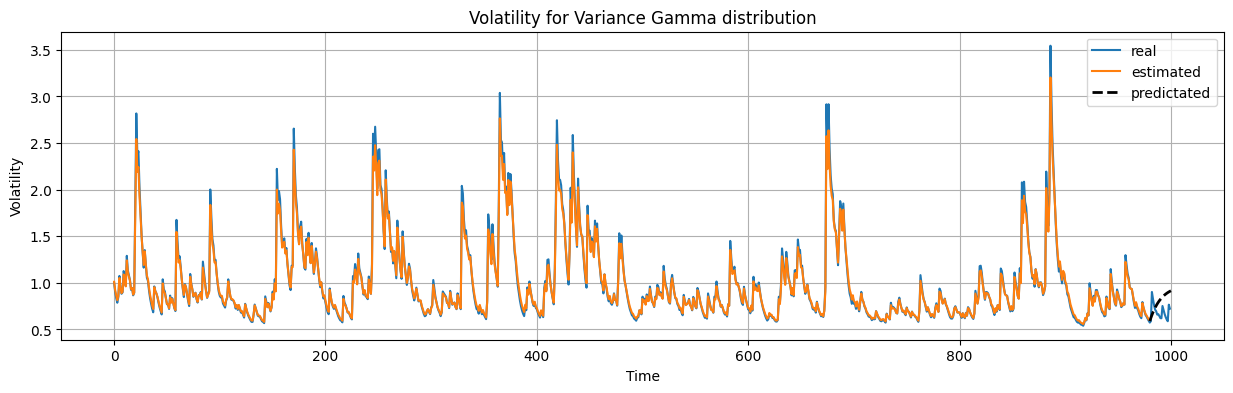

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_vg, label="real")
plt.plot(cond_vol_vg, color='tab:orange', label="estimated")

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS)
plt.plot(x_predicted, forecast_vg, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title("Volatility for Variance Gamma distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Среднеквадратичная ошибка оценки волатильности

In [62]:
norm_mse = ((vg_model.conditional_volatility - sigma2_vg[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.0023


#### Оценка параметров Variance Gamma распределения ($\mu,\ \sigma,\ \theta,\ \nu$)

In [63]:
def vg_moments_method(x):
	mu = np.mean(x)
	sigma_squared = np.mean( (x-mu)**2 )
	beta = np.mean( (x-mu)**3 ) / np.mean( (x-mu)**2 )**1.5
	kapa = np.mean( (x-mu)**4 ) / np.mean( (x-mu)**2 )**2
	sigma = sigma_squared**0.5
	nu = kapa/3.0 - 1.0
	theta = sigma*beta / (3.0*nu)
	c = mu - theta
	return (c, sigma, theta, nu)

vg_moments = vg_moments_method(std_resid_vg)
print("mu:", vg_moments[0], "sigma:", vg_moments[1], "theta:", vg_moments[2], "nu:", vg_moments[3])

mu: 0.04554906979540297 sigma: 1.0696414828646892 theta: -0.07663699251249405 nu: 0.8158161656371572


#### 3. $\alpha$-устойчивое распределение

В качестве $\alpha$ выберем 1.9

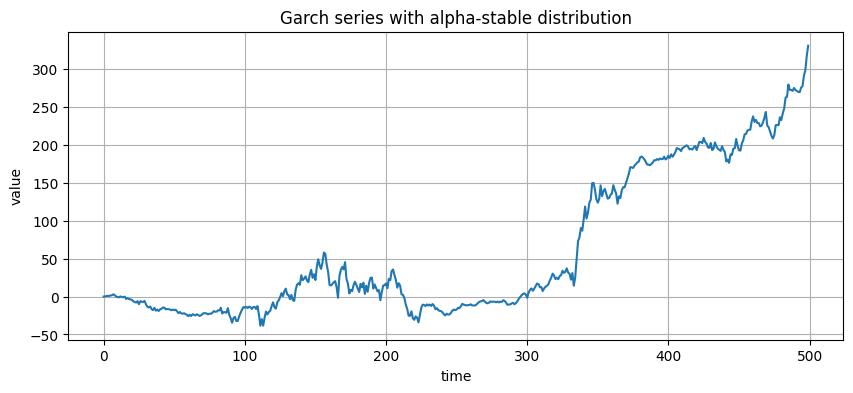

In [64]:
r_alpha_stable, sigma2_as = simulate_garch_process(OMEGA, ALPHA, BETA, 500, stats.levy_stable.rvs, 1.9, 0, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_alpha_stable))
plt.title("Garch series with alpha-stable distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [65]:
as_model = garch11(dist='as')
as_model.fit(r_alpha_stable[:-PREDICTION_STEPS])
as_model.summary()

'mu: -1.0056867468607974e-08, omega: 0.0065129005985692275, alpha: 0.1659367539508388, beta: 0.772074893525233'

In [66]:
forecast_as = as_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_as)


Прогноз дисперсии на 20 шагов:
[42.92479879 40.27047413 37.78068668 35.44523706 33.25455811 31.19967574
 29.27217214 27.46415132 25.76820672 24.17739094 22.68518721 21.28548273
 19.97254362 18.74099145 17.58578116 16.50218046 15.48575038 14.53232713
 13.63800501 12.79912045]


In [67]:
resid_as = as_model.resid  # r_t
cond_vol_as = as_model.conditional_volatility  # sigma_t
std_resid_as = resid_as / cond_vol_as # z_t

#### График оценённой волатильности / реальной

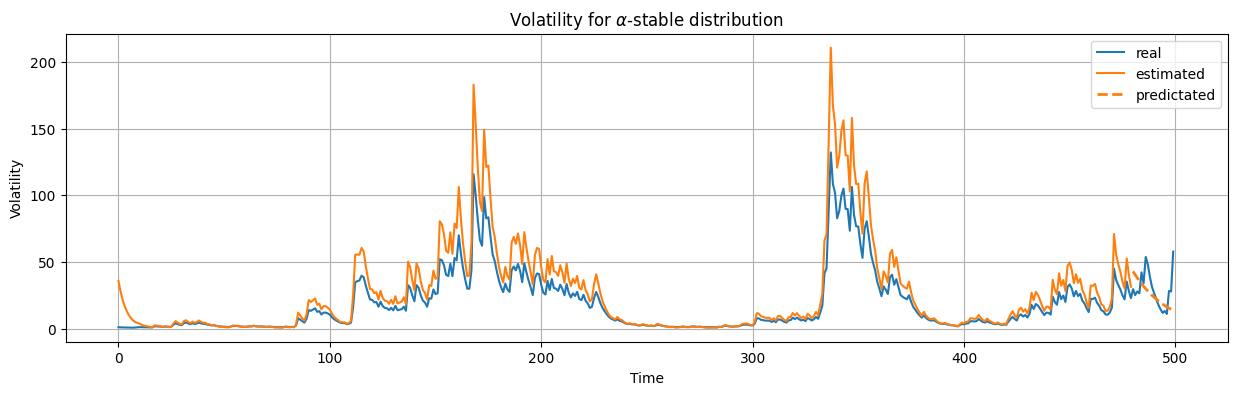

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_as, label="real")
plt.plot(cond_vol_as, color='tab:orange', label="estimated")

x_predicted = np.linspace(len(sigma2_as) - PREDICTION_STEPS, len(sigma2_as), PREDICTION_STEPS)
plt.plot(x_predicted, forecast_as, color='tab:orange', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for $\alpha$-stable distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Оценка параметров распределения

In [71]:
moments = stats.levy_stable.fit(std_resid_as)
print(rf"$\mu$ = {moments[2]}, $\alpha$ = {moments[0]}, $\sigma$ = {moments[3]}, $\beta$ = {moments[1]}, ")

$\mu$ = 0.0722718383617989, $\alpha$ = 1.2653231727552894, $\sigma$ = 0.2521392985922253, $\beta$ = 0.10323145414955526, 


#### Среднеквадратчная ошибка волатильности

In [70]:
norm_mse = ((as_model.conditional_volatility - sigma2_as[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 189.9487


## 3. GARCH(1,1) на реальных данных

### 3.1. Нормальное распределение

In [107]:
returns_nonscaled = returns['MSFT']
returns_scaled = returns['MSFT'] * 100

In [108]:
real_norm_model = garch11(dist='norm')
real_norm_model.fit(returns_scaled.to_numpy()[:-PREDICTION_STEPS])
real_norm_model.summary()

'mu: 0.11500932936368471, omega: 0.1487726696911392, alpha: 0.05933466357741768, beta: 0.8747337082041682'

In [117]:
resid_r_norm = real_norm_model.resid  # r_t
cond_vol_r_norm = real_norm_model.conditional_volatility  # sigma_t
std_resid_norm = resid_r_norm / cond_vol_r_norm # z_t

In [118]:
forecast_r_norm = real_norm_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_r_norm)


Прогноз дисперсии на 20 шагов:
[2.05334137 2.0667339  2.07924344 2.0909282  2.10184257 2.11203734
 2.12155995 2.13045472 2.13876304 2.14652358 2.15377245 2.1605434
 2.16686792 2.17277546 2.17829351 2.18344774 2.18826215 2.19275913
 2.19695962 2.20088316]


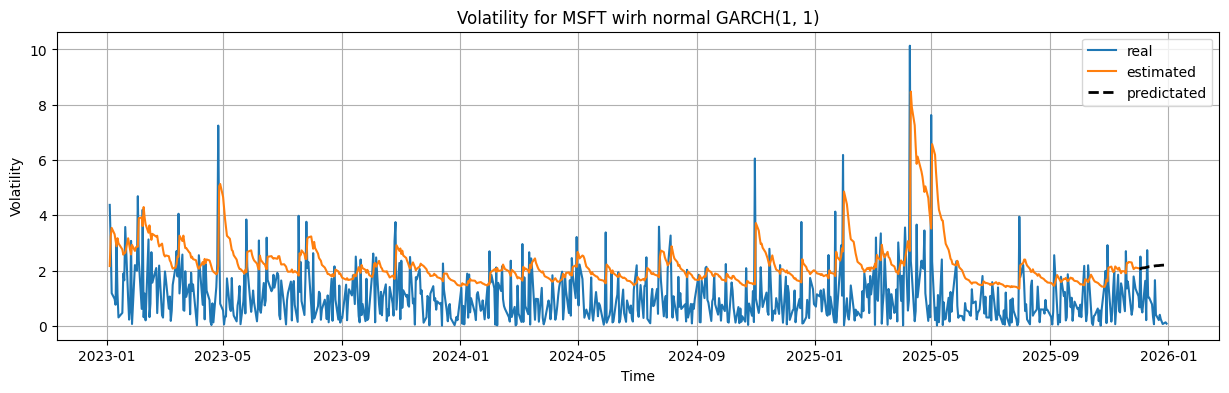

In [119]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(np.abs(returns_scaled), label="real")
plt.plot(returns_scaled.index[:-PREDICTION_STEPS], cond_vol_r_norm, color='tab:orange', label="estimated")
plt.plot(returns_scaled.index[-PREDICTION_STEPS:], forecast_r_norm, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for MSFT wirh normal GARCH(1, 1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

### 3.2. Variance Gamma

In [130]:
real_vg_model = garch11(dist='vg')
real_vg_model.fit(returns_scaled.to_numpy()[:-PREDICTION_STEPS])
real_vg_model.summary()

'mu: 0.4817587623649579, omega: 1.0434730229255014, alpha: 0.008665870981352708, beta: 0.1589369903503611'

In [131]:
resid_r_vg = real_vg_model.resid  # r_t
cond_vol_r_vg = real_vg_model.conditional_volatility  # sigma_t
std_resid_vg = resid_r_vg / cond_vol_r_vg # z_t

In [132]:
forecast_r_vg = real_vg_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_r_vg)


Прогноз дисперсии на 20 шагов:
[1.26294926 1.25514693 1.25383924 1.25362007 1.25358333 1.25357718
 1.25357614 1.25357597 1.25357594 1.25357594 1.25357594 1.25357594
 1.25357594 1.25357594 1.25357594 1.25357594 1.25357594 1.25357594
 1.25357594 1.25357594]


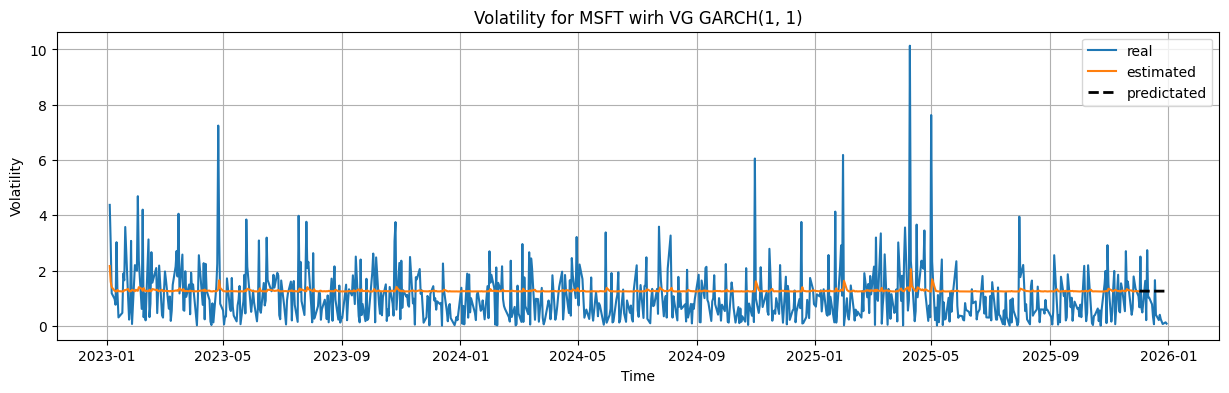

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(np.abs(returns_scaled), label="real")
plt.plot(returns_scaled.index[:-PREDICTION_STEPS], cond_vol_r_vg, color='tab:orange', label="estimated")
plt.plot(returns_scaled.index[-PREDICTION_STEPS:], forecast_r_vg, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for MSFT with VG GARCH(1, 1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

### 3. $\alpha$-устойчивое распределение

In [134]:
real_as_model = garch11(dist='as')
real_as_model.fit(returns_scaled.to_numpy()[:-PREDICTION_STEPS])
real_as_model.summary()

'mu: 0.12779958788474377, omega: 0.09154359658924174, alpha: 0.026360744206983776, beta: 0.8490879028081099'

In [135]:
resid_r_as = real_as_model.resid  # r_t
cond_vol_r_as = real_as_model.conditional_volatility  # sigma_t
std_resid_as = resid_r_as / cond_vol_r_as # z_t

In [136]:
forecast_r_as = real_as_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_r_as)


Прогноз дисперсии на 20 шагов:
[0.92316949 0.89973108 0.87921195 0.86124851 0.84552244 0.83175507
 0.81970245 0.809151   0.79991374 0.791827   0.78474747 0.77854971
 0.77312389 0.76837386 0.76421545 0.76057498 0.75738793 0.75459784
 0.75215525 0.75001689]


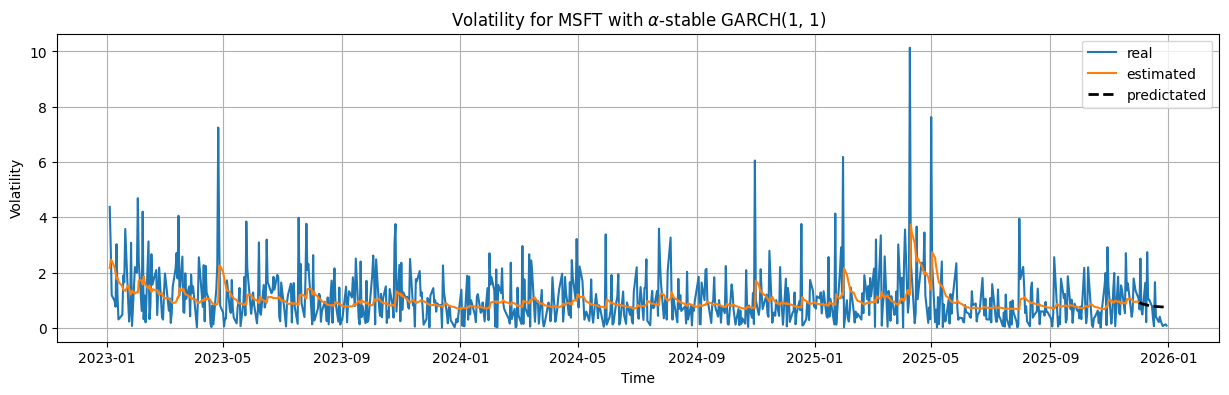

In [138]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(np.abs(returns_scaled), label="real")
plt.plot(returns_scaled.index[:-PREDICTION_STEPS], cond_vol_r_as, color='tab:orange', label="estimated")
plt.plot(returns_scaled.index[-PREDICTION_STEPS:], forecast_r_as, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for MSFT with $\alpha$-stable GARCH(1, 1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()